# BQ 101: An Introduction to the BlueQubit Platform

In this tutorial, we provide an overview of how to use the BlueQubit platform to simulate quantum circuits. To make this tutorial accessible for everyone, we'll first review some basic quantum computing terminology.


## From Bits to Qubits

The basic unit of information in quantum computing is carried by a **qubit** (quantum bit). What makes qubits fundamentally different from classical bits is the Principle of **Superposition**: The state of a qubit is in general given by a _linear combination_ of two orthogonal states $|0 \rangle$ and $|1\rangle$. Denoting the state by $|\psi \rangle$, we have that

$$|\psi \rangle = \alpha |0\rangle + \beta |1\rangle,$$ where $\alpha$ and $\beta$ are complex numbers satisfying $|\alpha|^2 + |\beta|^2 = 1$. Upon measuring the qubit, the statevector $|\psi\rangle$ collapses, and we observe either $|0\rangle$ or $|1\rangle$ with respective probabilities $|\alpha|^2$ and $|\beta|^2$. 



### Product States and Entangled States

When we have two qubits $q_0$ and $q_1$, with states $|\psi_0 \rangle$ and $|\psi_1 \rangle$ respectively, we can form their **product state** \begin{equation} |\pi \rangle = |\psi_0\rangle \otimes |\psi_1\rangle. \label{eq:prod_state} \tag{1} \end{equation}

For example, when $q_0$ and $q_1$ are both $|0\rangle$, their product state $|0\rangle \otimes |0\rangle$ is simply denoted by $|00\rangle$. Likewise, we have product states $|01\rangle$, $|10\rangle$, and $|11\rangle$; any state of a two-qubit system can in fact be expressed as a linear combination of these four (orthogonal) states. 

More generally, the state of an $n$-qubit system can be expressed as a linear combination of the $2^n$ product states $|00\ldots 0\rangle, |00\ldots 1\rangle, \ldots, |11\ldots 1\rangle$ --  i.e., the state is represented by a complex vector $|\psi\rangle$ of dimension $2^n$.


Let us now consider the **Bell state**: $$\frac{1}{\sqrt 2}(|00 \rangle + |11 \rangle).$$ It can be shown that the Bell state is _not a product state_ of the form $\eqref{eq:prod_state}$ for _any choice_ of states $|\psi_0 \rangle$ and $|\psi_1 \rangle$. Furthermore, upon measurement, we either get $q_0 = |0\rangle$ _and_ $q_1 = |0 \rangle$ or  $q_0 = |1\rangle$ _and_ $q_1 = |1 \rangle$, i.e., the measurement outcomes of different qubits are perfectly correlated. We say that the Bell state is an **entangled state**. 

This property of entanglement is a key resource that gives quantum computers their potential for an exponential advantage over classical ones. Creation and careful manipulation of entangled states lie at the heart of most quantum algorithms.  

## Manipulating quantum states: Quantum Gates

Just as classical computers use logic gates (like AND, NOT, or XOR) to operate on bits, quantum computers use **quantum gates** to manipulate qubits. These quantum operations are described by the rules of linear algebra. Thus, each quantum gate can be represented by a matrix, which corresponds to the linear operator that acts on the qubits' state.   

### A few basic gates

#### 1-qubit gates

* The analog of NOT gate is the $X$-gate, which flips the states $|0 \rangle$ and $|1\rangle$. Its matrix is $\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$

* The $Z$-gate preserves $|0 \rangle$, but flips the sign of $|1 \rangle$, i.e., it is represented by the diagonal matrix $\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$.

* There is also the $Y$-gate, which has matrix form $Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}$.

The three gates $X$, $Y$, and $Z$ constitute the **Pauli gates**. 

* The **Hadamard gate** creates equal superpositions: $H |0 \rangle = \frac{1}{\sqrt 2} (|0\rangle + |1\rangle)$ and $H |1 \rangle = \frac{1}{\sqrt 2} (|0\rangle - |1\rangle)$. Hence its matrix representation is $$H = \frac{1}{\sqrt 2} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}.$$


<div class="alert alert-block alert-secondary">

➕ _Exercise_: If you're feeling algebraically adventurous(!), verify the following relations among the above gates:

1. $X^2 = Y^2 = Z^2 = H^2 = I$
2. $XY = iZ = -YX; \quad YZ = iX = -ZY; \quad ZX = iY = -XZ$.
3. $X^H = Z; \quad Z^H = X; \quad Y^H = -Y.$ (Here, $X^H$ denotes the conjugate $H^\dagger X H$ etc.)

</div>

#### 2-qubit gates

The controlled-$X$ gate, or $CX$-gate, also known as CNOT-gate, applies $X$-gate to the _target qubit_ $q_1$ if the _control qubit_ $q_0$ is in state $|1\rangle$, otherwise it acts as the identity. The matrix representation of $CX$-gate (in the product basis $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle \}$) is 

$$CX_{\;q_0, \;q_1} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

_Note_: Here we are using the **little-endian** convention where lower qubit indices are less significant; for example, the product state $|01\rangle$ denotes $q_1$ in state $|0\rangle$ and $q_0$ in $|1\rangle$.

Likewise, we have the contolled-$Z$ gate, or $CZ$-gate, which applies the $Z$ gate on the target qubit $q_1$ if the control qubit $q_0$ is $|1\rangle$,

$$CZ_{\;q_0, \;q_1} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix}$$


### Quantum Circuits and Simulations

A **quantum circuit** consists of a series of gates acting on a set of qubits. The gates are applied sequentially, corresponding to the time evolution of the initial state under quantum mechanical laws. In a quantum device, at the end of the circuit run, qubits are measured to obtain the data needed to infer the evolved quantum state, enabling the computation of the expectation value(s) for given observable(s).

A **simulator** mimics this process by computationally evolving a mathematical representation of the quantum state. It does this by applying the equivalent of each gate to the state, which is usually represented by linear algebraic data, and finally performing calculations amounting to the computation of the expectation value for a given observable.

The simplest simulator is the **StateVector Simulator** which works with the full statevector $|\psi\rangle$ of the $n$-qubit system, thereby providing an exact simulation of the quantum circuit. However, since the statevector is of complex dimension $2^n$, this method requires $\mathcal O(2^n)$ bytes of memory, and thus becomes infeasible when the number of qubits becomes large (more than ~35 qubits). 



## A few Canonical Circuits

Let us construct some basic (yet interesting) circuits, and verify some of the things we have alluded to so far. We begin by creating the Bell State. But first, we initialize the BlueQubit API as follows.

In [1]:
import bluequbit


# initialize the BQ API
bq = bluequbit.init()

[BQ-PYTHON-SDK][WARNING] - Beta version 0.17.0b1.post1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Using execution mode from environment variable BLUEQUBIT_EXECUTION_MODE: local


[BQ-PYTHON-SDK][WARNING] - Using custom endpoint https://dev.app.bluequbit.io/api/v1


In [2]:
from qiskit import QuantumCircuit


# Create a circuit with two qubits in it.
# Each qubit is initialized to the |0⟩ state by default.
qc = QuantumCircuit(2)

# To create the Bell state, apply the Hadamard gate to q_0 followed by the CX gate on (q_0, q_1)
qc.h(0)
qc.cx(0, 1)

print("A circuit that creates the Bell state:")
qc.draw()

A circuit that creates the Bell state:


┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

### Running a circuit

Next, we run the circuit using the `bq.run()` method. By providing the `shots` parameter, the final state will be sampled from that many times  independently, and a dictionary of outcomes and their counts will be returned. 

In [4]:
# run the circuit by providing shots.

result = bq.run(qc, shots=10**4)
sample_counts = result.get_counts()

# print sample counts and verify that the counts for '00' and '11' are approximately equal
print("sample counts =", sample_counts)

sample counts = {'00': 4975, '11': 5025}


### Creating a Uniform Superposition

Let us now make a two-qubit circuit that creates a uniform superposition of the four 2-qubit computational basis states $|00\rangle, |01\rangle, |10\rangle$, and $|11\rangle$. This means that we want to create the state $$|\psi\rangle = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle +  |11\rangle).$$ Notice that $|\psi \rangle$ is in fact a product state, admitting the following factorization:

$$ \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle +  |11\rangle) = \frac{1}{\sqrt 2} (|0 \rangle + |1\rangle) \otimes \frac{1} {\sqrt 2} (|0 \rangle + |1\rangle).$$ Therefore, we just need to apply the Hadamard gate to both the qubits!

In [5]:
qc = QuantumCircuit(2)

# apply Hadamard gate to both qubits to create a uniform superposition of the basis states
qc.h(0)
qc.h(1)

qc.draw()

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     └───┘

In [6]:
# Verify that the counts for '00', '01', '10', and '11' are indeed approximately equal

result = bq.run(qc, shots=10**4)
samples = result.get_counts()

print("samples =", samples)

samples = {'00': 2513, '01': 2436, '10': 2619, '11': 2432}


In [7]:
# Let us also print the statevector, and convince ourselves that we really have the state that we set out to create.

# run without specifying shots for retrieving the statevector
result = bq.run(qc)

print(f"Statevector: {result.get_statevector()}")

Statevector: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]


### Coin-toss circuit

Generalizing the above construction, we can create what is called the **coin-toss circuit** for any $n$, consisting of a single layer of Hadamard gates on $n$ qubits. It prepares the state $(\frac{1}{\sqrt 2} (|0\rangle + |1\rangle))^{\otimes n}$, which is the uniform superposition of all the computational basis states for $n$-qubits.  

In [8]:
def coin_toss(n: int = 1) -> QuantumCircuit:
    """Return circuit that performs n coin tosses

    :param n: The number of coin tosses.
    :return: Circuit performing ``n`` coin tosses
    """
    qc = QuantumCircuit(n)
    qc.h(range(n))
    return qc


# Set up the coin-toss experiment
num_tosses = 16
coin_toss_qc = coin_toss(n=num_tosses)

num_samples = 10**4

# run the circuit and collect num_samples-many independent coin-toss sequences
results = bq.run(coin_toss_qc, shots=num_samples)
samples = results.get_counts()

#### Analyze data from the coin-toss experiment

Instead of looking at the counts of each outcome, we will count the number of '0's (which can be thought of as 'heads', say) in the samples. Since the samples are drawn independently, we should expect to see a nice, unbiased ($p=0.5$), binomial distribution for the number of '0's among the samples. 

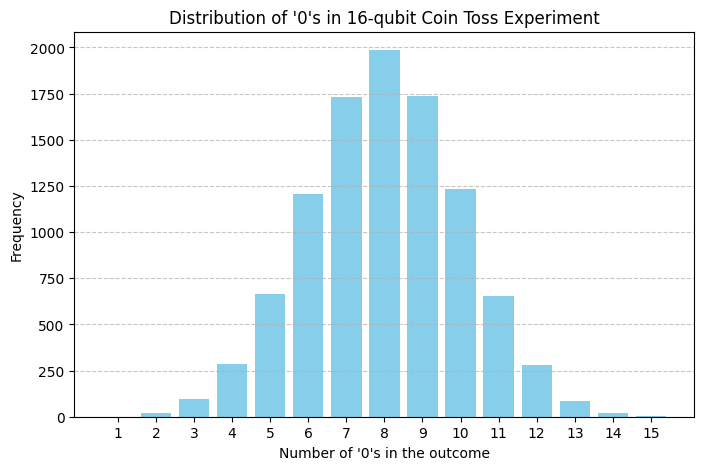

In [9]:
from collections import defaultdict

import matplotlib.pyplot as plt


# Dictionary to store the frequency of '0' counts
zeros_counts = defaultdict(int)

# Iterate through the samples and count the number of '0's in each outcome
for outcome, frequency in samples.items():
    num_zeros = outcome.count("0")
    zeros_counts[num_zeros] += frequency

# Sort the results by the number of zeros for plotting
sorted_zeros_counts = sorted(zeros_counts.items())
num_zeros_list = [item[0] for item in sorted_zeros_counts]
frequency_list = [item[1] for item in sorted_zeros_counts]

# Plot the histogram
plt.figure(figsize=(8, 5))
plt.bar(num_zeros_list, frequency_list, color="skyblue")
plt.xlabel("Number of '0's in the outcome")
plt.ylabel("Frequency")
plt.title(f"Distribution of '0's in {num_tosses}-qubit Coin Toss Experiment")
plt.xticks(range(min(num_zeros_list), max(num_zeros_list) + 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)

### GHZ-circuit

We saw earlier that statevector simulations, like the ones we ran above, are constrained by memory requirements to have around 35 qubits or fewer. So how does one move past this limit and simulate circuits with larger number of qubits? One solution is offered by **Matrix Product State (MPS)** simulations. One can think of MPS as 'compressed statevector', with compression achieved by the Singular Value Decomposition (SVD) algorithm, which is performed during each gate application. 

On the BQ platform, one can set `device = 'mps.cpu'` to perform MPS simulations.  


The **GHZ state** is an important generalization of the Bell state and is an example of multipartite quantum entanglement. For $n$ qubits, it is a superposition of all qubits being in the $|0\rangle$ state and all qubits being in the $|1\rangle$ state. 

The 3-qubit GHZ state is written as:

$$|GHZ_3 \rangle= \frac{1}{\sqrt 2} (|000 \rangle +|111 \rangle).$$

Let us create a 40-qubit GHZ-state and run it with MPS! 


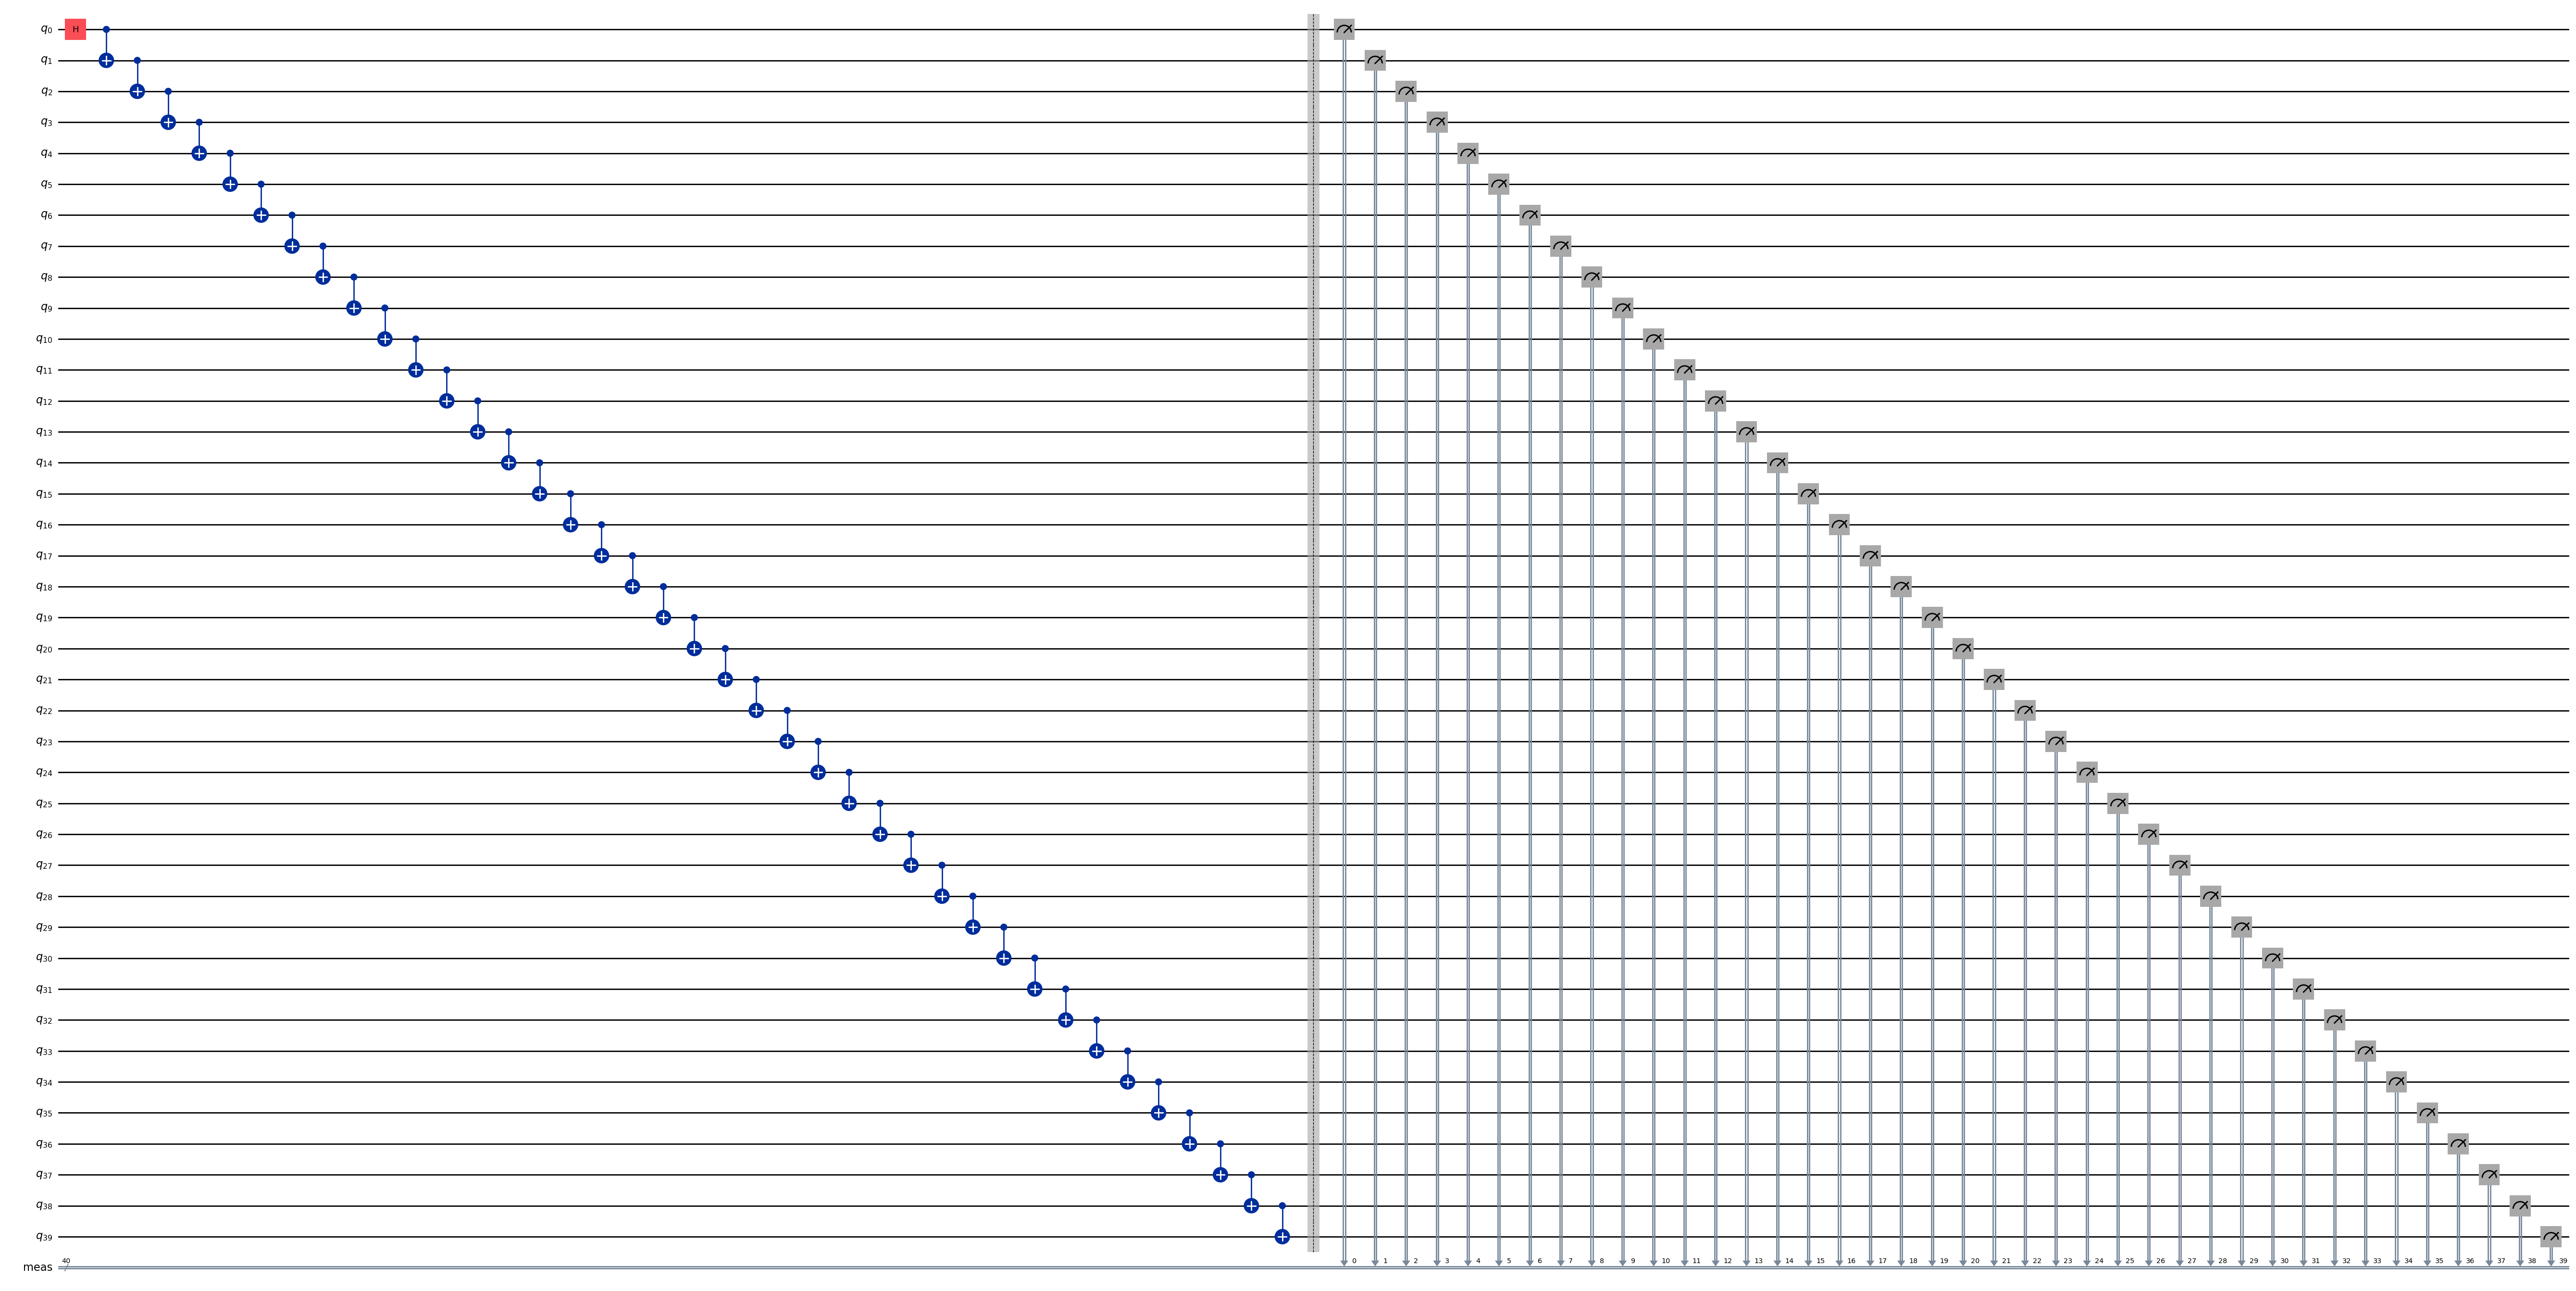

In [10]:
# A 40 qubit GHZ state
num_qubits = 40
qc = QuantumCircuit(num_qubits)

qc.h(0)
for i in range(num_qubits - 1):
    qc.cx(i, i + 1)

qc.measure_all()

qc.draw("mpl", fold=100)

In [11]:
# Provide bond dimension for MPS simulation using the 'options' parameter.
# Roughly speaking, bond dimension determines the degree of compression in the SVD step
options = {
    "mps_bond_dimension": 2,
}
result = bq.run(qc, device="mps.cpu", options=options, shots=1000)  # should take ~15 seconds
print("counts = ", result.get_counts())

counts =  {'1111111111111111111111111111111111111111': 502, '0000000000000000000000000000000000000000': 498}


### Computing Expectation Values

So how do we know that the state we just created is indeed $\frac{1}{\sqrt 2} (|00\ldots 0\rangle + |11\ldots1\rangle)$ and not perhaps $\frac{1}{\sqrt 2} (|00\ldots 0\rangle - |11\ldots1\rangle)$? After all, these two states both have identical outcome probability distributions! 

One can actually distinguish these two states by an expectation value computation. For example, consider the observable $O = XX\ldots X$, consisting of Pauli operator $X$ at each qubit. The first state is an eigenstate of $O$ with eigenvalue 1.0, whereas the second is an eigenstate with eigenvalue -1.0. 

💡To compute expectation values, one just needs to specify the `pauli_sum` parameter of `bq.run()`. 

Let's see what we get for the above circuit. 

In [12]:
# remove final measurements to compute expectation values
qc.remove_final_measurements(inplace=True)

# define the observable
obs = [("X" * qc.num_qubits, 1.0)]

result = bq.run(qc, device="mps.cpu", pauli_sum=obs, options=options)
print("expectation value =", result.expectation_value)

expectation value = 1.0


Let's try the same with a circuit that creates the 'minus GHZ-state' $\frac{1}{\sqrt 2} (|00\ldots 0\rangle - |11\ldots1\rangle)$. 

In [13]:
num_qubits = 40
qc_minus = QuantumCircuit(num_qubits)

# To create the 'minus GHZ-state', apply X-gate to q_0. The rest of the circuit is the same.
qc_minus.x(0)
qc_minus.h(0)
for i in range(num_qubits - 1):
    qc_minus.cx(i, i + 1)


result_minus = bq.run(qc_minus, device="mps.cpu", pauli_sum=obs, options=options)
print("expectation value =", result_minus.expectation_value)

expectation value = -1.0


## More Simulators

We end by providing a list of all simulators (devices) that are available on the BQ platform:

`device='cpu'` (default), `device='gpu'`, `device='mps.cpu'`, `device='mps.gpu'`, and `device='pauli-path'`.

⚛️ One can also access actual quantum devices through the BQ platform with `device='quantum'`! 

➡️ To learn more about how to use the `pauli-path` device and run Pauli-Path Simulations, we refer to our [tutorial on Pauli-Path Simulations](https://app.bluequbit.io/tutorial/2tmSchlAGgRBTKxC "PPS tutorial")

🔗 To see simple example usages of some of the other simulators, have a look at our [SDK docs](https://app.bluequbit.io/sdk-docs/index.html "SDK doc examples")